# Representation analysis

### Full solution prediction

conclusion: all small models hallucinate

In [1]:
import os
import pandas as pd
import numpy as np
from llm import LLMPredictor, TransformersBackend, LlamaCppBackend
from evaluation import eval_repr_benchmark, repr_benchmark_summary
from search import astar, beam_search, llm_astar, llm_beam
from core import load_microban

gemma_path = os.environ.get("GEMMA_PATH")
nemtron_path = os.environ.get("NEMTRON_PATH")
# gemma_path = "/Users/mernahafez/.lmstudio/models/lmstudio-community/gemma-3n-E4B-it-text-GGUF/gemma-3n-E4B-it-Q4_K_M.gguf"
# nemtron_path = "/Users/mernahafez/.lmstudio/models/lmstudio-community/NVIDIA-Nemotron-3-Nano-4B-GGUF/NVIDIA-Nemotron-3-Nano-4B-Q4_K_M.gguf"

backend = LlamaCppBackend(
    model_path=nemtron_path,
    n_gpu_layers=-1,
    temperature=0.3,
    verbose=False
)

puzzles = load_microban("Microban.txt")
print(len(puzzles))          # 154

predictor = LLMPredictor(backend)

representations = [
        "01_ASCII_RAW",
        "02_ASCII_ROW_MARKERS",
        "03_RLE",
        "04_COORDINATE_LIST",
        "05_INDEXED_STATE",
        "06_GRAPH_ADJACENCY",
        "07_RELATIVE_SPATIAL",
        "08_TENSOR_FLATTEN",
        "09_SEMANTIC_SUMMARY",
        "10_COMPACT_SYMBOLIC",
        "11_BFS_ORDERED",
        "12_GRID_WITH_INDICES",
        "13_ACTION_CENTRIC",
        "14_BITBOARD_HEX",
        "15_BITBOARD_BINARY_ROWS",
        "16_BITBOARD_OVERLAID",
        "17_BITBOARD_MIXED",
        "18_BITBOARD_COMBINED"
    ]

rows = eval_repr_benchmark(
    puzzles   = puzzles[:2],
    predictor = predictor,
    repr_keys = representations,
)

df = pd.DataFrame(rows)

# Which repr gives the best solve rate?
df.groupby("repr_key")["solved"].mean().sort_values(ascending=False)

# Full heatmap: puzzle × repr
df.pivot(index="puzzle_name", columns="repr_key", values="solved")

# Ranked summary table
repr_benchmark_summary(rows)

## Representation selection using LLamaCPP for faster inference

df = pd.DataFrame(rows)
print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)

# 1. Which repr gives the best solve rate?
print("\nSolve Rate by Representation:")
solve_rates = df.groupby("repr_key")["solved"].mean().sort_values(ascending=False)
print(solve_rates.round(3))

# 2. Best by partial credit (boxes placed)
print("\nBoxes Placed (Partial Credit):")
box_scores = df.groupby("repr_key")["boxes_placed_pct"].mean().sort_values(ascending=False)
print(box_scores.round(3))

# 3. Best by valid moves percentage
print("\nValid Move Percentage:")
valid_scores = df.groupby("repr_key")["valid_prefix_pct"].mean().sort_values(ascending=False)
print(valid_scores.round(3))

# 4. Combined score (weighted)
print("\nCombined Score (Solve% + Boxes% + Valid%):")
df["combined_score"] = df["solved"] + df["boxes_placed_pct"] + df["valid_prefix_pct"]
combined = df.groupby("repr_key")["combined_score"].mean().sort_values(ascending=False)
print(combined.round(3))

# 5. Full heatmap
print("\nHeatmap: Puzzle × Representation (Solve Rate)")
heatmap = df.pivot(index="puzzle_name", columns="repr_key", values="solved")
print(heatmap)

# 6. Ranked summary table
print("\nRANKED SUMMARY TABLE:")
repr_benchmark_summary(rows)

# 7. Top 3 recommendations
print("\n" + "="*60)
print("TOP 3 RECOMMENDATIONS:")
top3 = solve_rates.head(3).index.tolist()
for i, repr_key in enumerate(top3, 1):
    solve_rate = solve_rates[repr_key]
    box_pct = box_scores[repr_key]
    print(f"  {i}. {repr_key}: Solve={solve_rate:.1%}, Boxes={box_pct:.1%}")

print("\n✓ Benchmark complete!")

✓ Metal GPU acceleration enabled


llama_context: n_ctx_seq (2048) < n_ctx_train (1048576) -- the full capacity of the model will not be utilized
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 1024


  [microban] Skipping puzzle "155 'The Dungeon'": (8, 8)
154

  Puzzle 1 (7x6, boxes=2, medium)  optimal=8P
Predicted solution: FullSolutionResult(solution='dlURRr', len=6, pushes=3, ok=True)
    [~] 01_ASCII_RAW                    solved=False  boxes=1/2  valid=6/6  best_h=4  opt=—  latency=3786ms
Predicted solution: FullSolutionResult(solution='dlURRr', len=6, pushes=3, ok=True)
    [~] 02_ASCII_ROW_MARKERS            solved=False  boxes=1/2  valid=6/6  best_h=4  opt=—  latency=2708ms
Predicted solution: FullSolutionResult(solution='dlURRr', len=6, pushes=3, ok=True)
    [~] 03_RLE                          solved=False  boxes=1/2  valid=6/6  best_h=4  opt=—  latency=2301ms
Predicted solution: FullSolutionResult(solution='dlURRr', len=6, pushes=3, ok=True)
    [~] 04_COORDINATE_LIST              solved=False  boxes=1/2  valid=6/6  best_h=4  opt=—  latency=3525ms
Predicted solution: FullSolutionResult(solution='dlURRr', len=6, pushes=3, ok=True)
    [~] 05_INDEXED_STATE                

llama_context: n_ctx_seq (2048) < n_ctx_train (1048576) -- the full capacity of the model will not be utilized
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 1024


✓ Metal GPU acceleration enabled
  [microban] Skipping puzzle "155 'The Dungeon'": (8, 8)

STEP-BY-STEP REPRESENTATION BENCHMARK
Puzzles: 10
Representations: 18
Max steps per puzzle: 20

  Puzzle 1 (7x6, 2 boxes)
    [01_ASCII_RAW        ] Model predicted move NextMoveResult(move='R' (push), conf=0.95, ok=True)
Model predicted move NextMoveResult(move='U' (push), conf=0.95, ok=True)
✗ steps= 1 boxes=1/2 latency=6260ms
    [02_ASCII_ROW_MARKERS] Model predicted move NextMoveResult(move='U' (push), conf=0.95, ok=True)
Model predicted move NextMoveResult(move='U' (push), conf=0.95, ok=True)
Model predicted move NextMoveResult(move='U' (push), conf=0.95, ok=True)
✗ steps= 2 boxes=1/2 latency=5418ms
    [03_RLE              ] Model predicted move NextMoveResult(move='U' (push), conf=0.95, ok=True)
Model predicted move NextMoveResult(move='R' (push), conf=0.95, ok=True)
✗ steps= 1 boxes=1/2 latency=6323ms
    [04_COORDINATE_LIST  ] Model predicted move NextMoveResult(move='R' (push), conf=0.

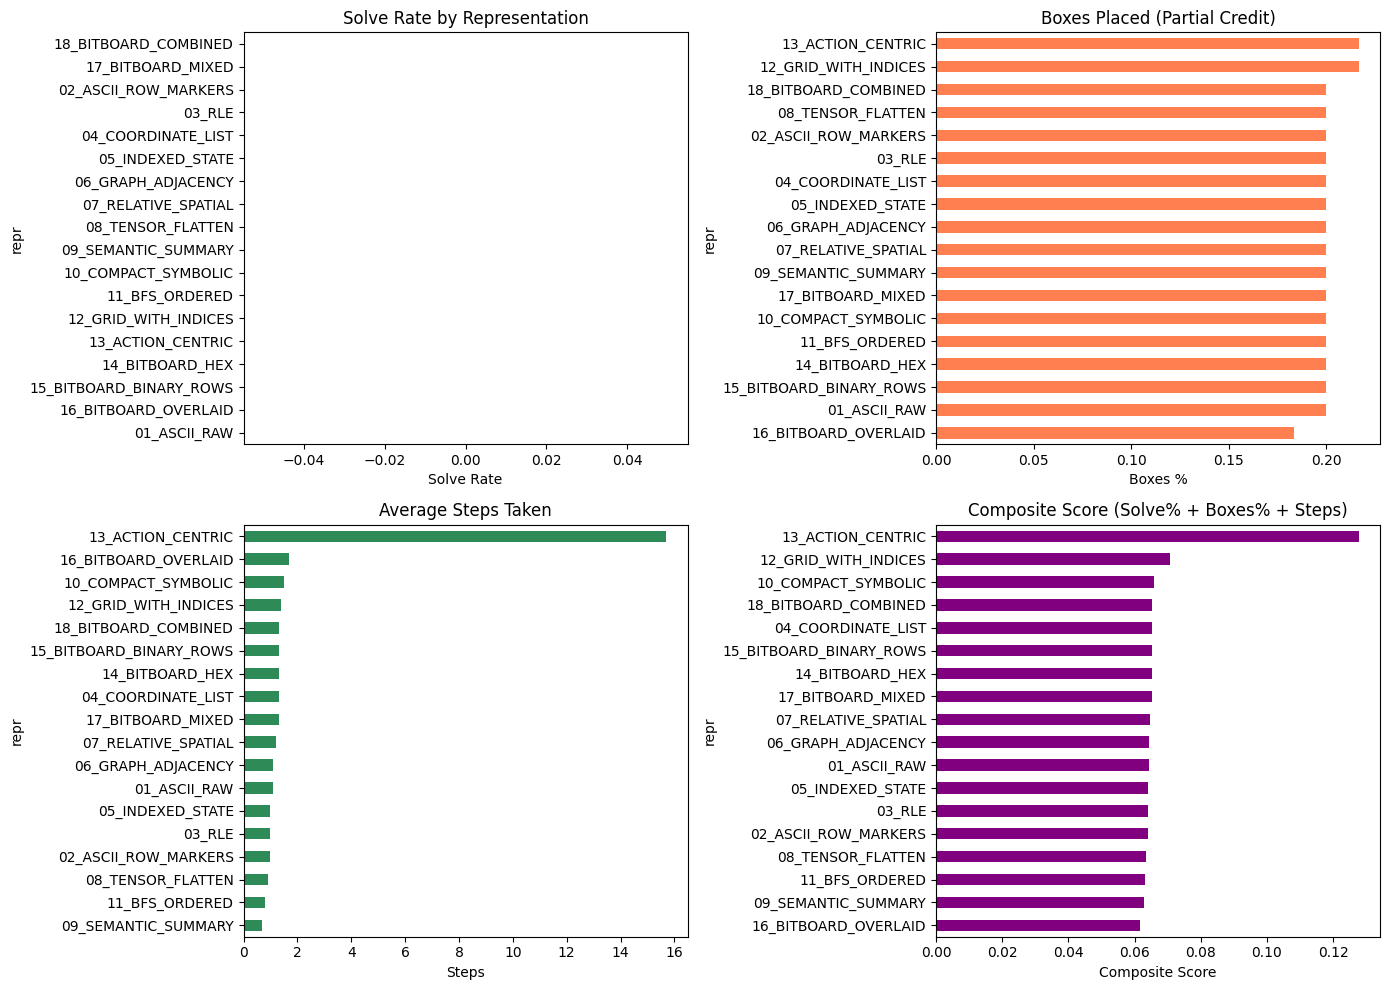


✅ Top 3 representations for search: ['13_ACTION_CENTRIC', '12_GRID_WITH_INDICES', '10_COMPACT_SYMBOLIC']


In [2]:
import pandas as pd
import numpy as np
from llm import LLMPredictor, TransformersBackend, LlamaCppBackend
from evaluation import eval_repr_benchmark, repr_benchmark_summary, run_step_benchmark
from search import astar, beam_search, llm_astar, llm_beam
from core import load_microban


nemtron_path = os.environ.get("NEMTRON_PATH")

backend = LlamaCppBackend(
    model_path=nemtron_path,
    n_gpu_layers=-1,
    temperature=0.3,
    verbose=False
)
predictor = LLMPredictor(backend)

representations = [
        "01_ASCII_RAW",
        "02_ASCII_ROW_MARKERS",
        "03_RLE",
        "04_COORDINATE_LIST",
        "05_INDEXED_STATE",
        "06_GRAPH_ADJACENCY",
        "07_RELATIVE_SPATIAL",
        "08_TENSOR_FLATTEN",
        "09_SEMANTIC_SUMMARY",
        "10_COMPACT_SYMBOLIC",
        "11_BFS_ORDERED",
        "12_GRID_WITH_INDICES",
        "13_ACTION_CENTRIC",
        "14_BITBOARD_HEX",
        "15_BITBOARD_BINARY_ROWS",
        "16_BITBOARD_OVERLAID",
        "17_BITBOARD_MIXED",
        "18_BITBOARD_COMBINED"
    ]

puzzles = load_microban("Microban.txt")

df, top3 = run_step_benchmark(
    puzzles=puzzles[:10],
    predictor=predictor,
    repr_keys=representations,
    max_steps=20,
    verbose=True,
)

print(f"\n✅ Top 3 representations for search: {top3}")

In [ ]:
import os
import pandas as pd
import numpy as np
from llm import LLMPredictor, TransformersBackend, LlamaCppBackend
from evaluation import eval_repr_benchmark, repr_benchmark_summary, run_step_benchmark
from search import astar, beam_search, llm_astar, llm_beam
from core import load_microban

gemma_path = os.environ.get("GEMMA_PATH")

backend = LlamaCppBackend(
    model_path=gemma_path,
    n_gpu_layers=-1,
    temperature=0.3,
    verbose=False
)
predictor = LLMPredictor(backend)

representations = [
        "01_ASCII_RAW",
        "02_ASCII_ROW_MARKERS",
        "03_RLE",
        "04_COORDINATE_LIST",
        "05_INDEXED_STATE",
        "06_GRAPH_ADJACENCY",
        "07_RELATIVE_SPATIAL",
        "08_TENSOR_FLATTEN",
        "09_SEMANTIC_SUMMARY",
        "10_COMPACT_SYMBOLIC",
        "11_BFS_ORDERED",
        "12_GRID_WITH_INDICES",
        "13_ACTION_CENTRIC",
        "14_BITBOARD_HEX",
        "15_BITBOARD_BINARY_ROWS",
        "16_BITBOARD_OVERLAID",
        "17_BITBOARD_MIXED",
        "18_BITBOARD_COMBINED"
    ]
    
puzzles = load_microban("Microban.txt")

df, top3 = run_step_benchmark(
    puzzles=puzzles[:5],
    predictor=predictor,
    repr_keys=representations,
    max_steps=20,
    verbose=True,
)

print(f"\n✅ Top 3 representations for search: {top3}")

✓ Metal GPU acceleration enabled


llama_context: n_ctx_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized
llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)


  [microban] Skipping puzzle "155 'The Dungeon'": (8, 8)

STEP-BY-STEP REPRESENTATION BENCHMARK
Puzzles: 5
Representations: 18
Max steps per puzzle: 20

  Puzzle 1 (7x6, 2 boxes)
    [01_ASCII_RAW        ] Model predicted move NextMoveResult(move='R' (push), conf=0.95, ok=True)
Model predicted move NextMoveResult(move='R' (push), conf=0.95, ok=True)
Model predicted move NextMoveResult(move=None (walk), conf=0.50, ok=False)
✗ steps= 2 boxes=1/2 latency=21281ms
    [02_ASCII_ROW_MARKERS] Model predicted move NextMoveResult(move='U' (push), conf=0.95, ok=True)
Model predicted move NextMoveResult(move='U' (push), conf=0.95, ok=True)
Model predicted move NextMoveResult(move='U' (push), conf=0.95, ok=True)
✗ steps= 2 boxes=1/2 latency=4165ms
    [03_RLE              ] Model predicted move NextMoveResult(move=None (walk), conf=0.50, ok=False)
✗ steps= 0 boxes=1/2 latency=N/A (no valid moves)
    [04_COORDINATE_LIST  ] Model predicted move NextMoveResult(move=None (walk), conf=0.50, ok=False)


### Full representation test

In [ ]:
import pandas as pd
import numpy as np
from llm import LLMPredictor, TransformersBackend, LlamaCppBackend
from evaluation import eval_repr_benchmark, repr_benchmark_summary, run_step_benchmark
from search import astar, beam_search, llm_astar, llm_beam
from core import load_microban

puzzles = load_microban("Microban.txt")

def full_pipeline_test():
    print("="*60)
    print("FULL PIPELINE TEST")
    print("="*60)
    
    # 1. Load puzzle
    puzzle = puzzles[0]
    board = puzzle.to_board()
    print(f"✓ Board loaded: {puzzle.height}x{puzzle.width}")
    
    # 2. Test move application
    test_move = "u"
    try:
        new_board, applied = board.apply_move(test_move)
        print(f"✓ Applied move '{test_move}' -> '{applied}'")
    except ValueError as e:
        print(f"✗ Move '{test_move}' failed: {e}")
        return
    
    # 3. Test state tracking
    print(f"\n  After move:")
    print(f"    Player: {board.player} -> {new_board.player}")
    print(f"    Boxes: {sorted(board.boxes)} -> {sorted(new_board.boxes)}")
    
    # 4. Test get_legal_moves
    moves = new_board.get_legal_moves()
    print(f"\n✓ get_legal_moves returns {len(moves)} moves")
    for lurd, state, zh, norm in moves[:3]:
        print(f"    {lurd}: player={state.player}, boxes={len(state.boxes)}")
    
    # 5. Test board._make_child
    child = board._make_child(state, zh, norm)
    print(f"\n✓ _make_child creates valid board")
    
    # 6. Test LLM prediction
    from llm import LLMPredictor, LlamaCppBackend
    
    nemtron_path = os.environ.get("NEMTRON_PATH")
    backend = LlamaCppBackend(
        model_path=nemotron_path,
        n_gpu_layers=-1,
        temperature=0.3,
        verbose=False
    )
    predictor = LLMPredictor(backend)
    
    result = predictor.predict_next_move(board, "13_ACTION_CENTRIC")
    print(f"\n✓ LLM prediction: {result.move} (conf={result.confidence})")
    
    # 7. Test apply LLM's move
    if result.move:
        try:
            new_board2, applied2 = board.apply_move(result.move)
            print(f"✓ Applied LLM move '{result.move}' -> '{applied2}'")
        except ValueError as e:
            print(f"✗ LLM move '{result.move}' illegal: {e}")
    
    print("\n" + "="*60)
    print("PIPELINE VERDICT: All core components working!")
    print("="*60)

full_pipeline_test()

  [microban] Skipping puzzle "155 'The Dungeon'": (8, 8)
FULL PIPELINE TEST
✓ Board loaded: 7x6
✓ Applied move 'u' -> 'u'

  After move:
    Player: (3, 2) -> (2, 2)
    Boxes: [(3, 1), (4, 3)] -> [(3, 1), (4, 3)]

✓ get_legal_moves returns 3 moves
    u: player=(1, 2), boxes=2
    d: player=(3, 2), boxes=2
    l: player=(2, 1), boxes=2

✓ _make_child creates valid board
✓ Metal GPU acceleration enabled for Apple Silicon


llama_context: n_ctx_seq (2048) < n_ctx_train (1048576) -- the full capacity of the model will not be utilized
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 1024



✓ LLM prediction: U (conf=0.95)
✓ Applied LLM move 'U' -> 'u'

PIPELINE VERDICT: All core components working!


In [ ]:
"""
Test LLM-guided search with FULL move expansion
A* returns push-only (ULURDLUU) but LLM needs to walk between pushes!
"""

import time
from core import load_microban
from llm import LLMPredictor, LlamaCppBackend
from search.astar import llm_astar, astar
from representations import get_repr
import pandas as pd

# Load puzzle
puzzles = load_microban("Microban.txt")
puzzle = puzzles[0]
board = puzzle.to_board()

print("="*60)
print(f"TESTING: Puzzle {puzzle.name}")
print("="*60)

# Display initial board
print("\nINITIAL BOARD:")
print(get_repr("01_ASCII_RAW")(board))

# Get optimal solution
print("\nComputing optimal solution (A*)...")
t0 = time.time()
optimal = astar(board)
optimal_time = time.time() - t0

# Expand to FULL moves (walks + pushes)
optimal_full_moves = optimal.expand_to_full_moves(board)
print(f"  Optimal pushes: {optimal.solution_length}")
print(f"  Optimal full moves: {len(optimal_full_moves)} (walks + pushes)")
print(f"  Full solution: {''.join(optimal_full_moves)}")
print(f"  Time: {optimal_time:.3f}s")

# Initialize predictor
nemtron_path = os.environ.get("NEMTRON_PATH")

backend = LlamaCppBackend(
    model_path=nemotron_path,
    n_gpu_layers=-1,
    temperature=0.3,
    verbose=False
)
predictor = LLMPredictor(backend)

# ============================================================
# TEST 1: LLM Alone (Zero-shot) - With board printing
# ============================================================
print("\n" + "="*60)
print("TEST 1: LLM Alone (No Search)")
print("="*60)

board = puzzle.to_board()
llm_moves = []
max_steps = 30

for step in range(max_steps):
    if board.is_solved():
        break
    
    # Print current board state
    print(f"\n--- Step {step+1} ---")
    print(get_repr("01_ASCII_RAW")(board))
    print(f"Player: {board.player}, Boxes on goals: {len(board.boxes_on_goals)}/{len(board.goals)}")
    
    # Get LLM prediction
    result = predictor.predict_next_move(board, "13_ACTION_CENTRIC")
    
    if not result.ok or result.move is None:
        print(f"  ❌ No valid move from LLM")
        break
    
    print(f"  LLM predicts: '{result.move}' (conf={result.confidence})")
    print(f"  Reasoning: {result.rationale[:100]}...")
    
    # Try to apply the move
    try:
        board, applied = board.apply_move(result.move)
        llm_moves.append(result.move)
        print(f"  Applied: '{applied}'")
    except ValueError as e:
        print(f"  ❌ Illegal move: {e}")
        break

zero_shot_solved = board.is_solved()
print(f"\n" + "="*40)
print(f"ZERO-SHOT RESULT: {'SOLVED!' if zero_shot_solved else 'NOT SOLVED'}")
print(f"  Moves made: {len(llm_moves)}")
print(f"  Boxes placed: {len(board.boxes_on_goals)}/{len(board.goals)}")
if not zero_shot_solved:
    print(f"  Final board:")
    print(get_repr("01_ASCII_RAW")(board))

# ============================================================
# TEST 2: LLM + Search (llm_astar)
# ============================================================
print("\n" + "="*60)
print("TEST 2: LLM + Search (llm_astar)")
print("="*60)

# First, let's check what llm_astar returns
print("\n  Running llm_astar...")
t0 = time.time()
result = llm_astar(
    board=puzzle.to_board(),
    predictor=predictor,
    repr_key="13_ACTION_CENTRIC",
    max_nodes=10000
)
search_time = time.time() - t0

print(f"\n  SEARCH RESULT:")
print(f"    Solved: {result.solved}")
print(f"    Push moves: {result.solution_length if result.solved else 0}")
if result.solved and result.moves:
    print(f"    Push sequence: {''.join(result.moves)}")
    print(f"    States tracked: {len(result.states)}")

# Expand push moves to full moves if solved
if result.solved:
    print(f"\n  Expanding to full moves...")
    try:
        full_moves = result.expand_to_full_moves(puzzle.to_board())
        print(f"    Full move sequence: {''.join(full_moves)}")
        print(f"    Full length: {len(full_moves)}")
        
        # Verify by playing
        board = puzzle.to_board()
        print(f"\n  VERIFYING SOLUTION STEP-BY-STEP:")
        for i, move in enumerate(full_moves):
            board, applied = board.apply_move(move)
            print(f"    {i+1:2d}: {move} -> player={board.player}, boxes={len(board.boxes_on_goals)}/{len(board.goals)}")
        
        if board.is_solved():
            print(f"\n  SOLUTION VERIFIED!")
        else:
            print(f"\n  ❌ SOLUTION FAILED VERIFICATION")
            
    except Exception as e:
        print(f"    ❌ Expansion failed: {e}")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

summary_data = []
# A* (push-only)
summary_data.append({
    "Method": "A* (push-only)",
    "Solved": optimal.solved,
    "Moves": optimal.solution_length,
    "Full Moves": len(optimal_full_moves) if optimal.solved else None,
    "LLM Calls": 0,
    "Time (s)": optimal_time,
})

# LLM Alone
summary_data.append({
    "Method": "LLM Alone",
    "Solved": zero_shot_solved,
    "Moves": len(llm_moves),
    "Full Moves": None,
    "LLM Calls": len(llm_moves),
    "Time (s)": None,
})

# LLM + Search
if result.solved:
    summary_data.append({
        "Method": "LLM + Search",
        "Solved": result.solved,
        "Moves": result.solution_length,
        "Full Moves": len(full_moves) if result.solved else None,
        "LLM Calls": result.llm_calls,
        "Time (s)": search_time,
    })

summary = pd.DataFrame(summary_data)
print(summary.to_string(index=False))

# Save results
if result.solved:
    with open(f"solution_{puzzle.name}_llm_search.txt", "w") as f:
        f.write(f"Puzzle: {puzzle.name}\n")
        f.write(f"Push-only solution: {''.join(result.moves)}\n")
        f.write(f"Full solution: {''.join(full_moves)}\n")
        f.write(f"Push count: {result.solution_length}\n")
        f.write(f"Full length: {len(full_moves)}\n")
        f.write(f"Time: {search_time:.2f}s\n")
        f.write(f"LLM Calls: {result.llm_calls}\n")
    print(f"\nSolution saved to solution_{puzzle.name}_llm_search.txt")

  [microban] Skipping puzzle "155 'The Dungeon'": (8, 8)
TESTING: Puzzle 1

INITIAL BOARD:
####  
# .#  
#  ###
#*@  #
#  $ #
#  ###
####  

📊 Computing optimal solution (A*)...
  Optimal pushes: 8
  Optimal full moves: 33 (walks + pushes)
  Full solution: dlUrrrdLullddrUluRuulDrddrruLdlUU
  Time: 0.001s
✓ Metal GPU acceleration enabled for Apple Silicon


llama_context: n_ctx_seq (2048) < n_ctx_train (1048576) -- the full capacity of the model will not be utilized
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 1024



TEST 1: LLM Alone (No Search)

--- Step 1 ---
####  
# .#  
#  ###
#*@  #
#  $ #
#  ###
####  
Player: (3, 2), Boxes on goals: 1/2
  🤖 LLM predicts: 'U' (conf=0.95)
  💭 Reasoning: There is an unsolved box at (4,3). The player is at (3,2), so moving up (U) pushes the box down to (...
  ✅ Applied: 'u'

--- Step 2 ---
####  
# .#  
# @###
#*   #
#  $ #
#  ###
####  
Player: (2, 2), Boxes on goals: 1/2
  🤖 LLM predicts: 'U' (conf=0.95)
  💭 Reasoning: ...
  ✅ Applied: 'u'

--- Step 3 ---
####  
# +#  
#  ###
#*   #
#  $ #
#  ###
####  
Player: (1, 2), Boxes on goals: 1/2
  🤖 LLM predicts: 'U' (conf=0.95)
  💭 Reasoning: ...
  ❌ Illegal move: Illegal move: 'U'

ZERO-SHOT RESULT: NOT SOLVED
  Moves made: 2
  Boxes placed: 1/2
  Final board:
####  
# +#  
#  ###
#*   #
#  $ #
#  ###
####  

TEST 2: LLM + Search (llm_astar)

  Running llm_astar...

  SEARCH RESULT:
    Solved: True
    Push moves: 8
    Push sequence: ULURDLUU
    States tracked: 8

  Expanding to full moves...
    Full move se

### LLM with history in the prompt to avoid loops

In [1]:
import time
from core import load_microban
from llm import LLMPredictor, LlamaCppBackend, HistoryAwareLLMPredictor
from search.astar import llm_astar, astar
from representations import get_repr

nemotron_path = "/Users/mernahafez/.lmstudio/models/lmstudio-community/NVIDIA-Nemotron-3-Nano-4B-GGUF/NVIDIA-Nemotron-3-Nano-4B-Q4_K_M.gguf"

backend = LlamaCppBackend(
    model_path=nemotron_path,
    n_gpu_layers=-1,
    temperature=0.3,
    verbose=False
)
predictor = LLMPredictor(backend)

puzzles = load_microban("Microban.txt")
puzzle = puzzles[0]
board = puzzle.to_board()

# Test with history
print("\n" + "="*60)
print("TEST: History-Aware LLM Predictor")
print("="*60)

history_predictor = HistoryAwareLLMPredictor(backend)

history_predictor.reset_history()

for step in range(50):
    if board.is_solved():
        print(f"\n✅ SOLVED in {step} steps!")
        break
    
    result = history_predictor.predict_next_move(board, "13_ACTION_CENTRIC", use_history=True)
    
    if not result.ok or result.move is None:
        print(f"\n❌ Failed at step {step}")
        break
    
    print(f"Step {step+1}: {result.move} (conf={result.confidence})")
    print(f"  History: {history_predictor.history}")
    
    try:
        board, _ = board.apply_move(result.move)
    except ValueError as e:
        print(f"  ❌ Illegal: {e}")
        break
    
    print(f"  Boxes: {len(board.boxes_on_goals)}/{len(board.goals)}")

print(f"\nFinal: {len(history_predictor.history)} moves made")

✓ Metal GPU acceleration enabled for Apple Silicon


llama_context: n_ctx_seq (2048) < n_ctx_train (1048576) -- the full capacity of the model will not be utilized
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 1024


  [microban] Skipping puzzle "155 'The Dungeon'": (8, 8)

TEST: History-Aware LLM Predictor
Step 1: U (conf=0.95)
  History: ['U']
  Boxes: 1/2
Step 2: U (conf=0.95)
  History: ['U', 'U']
  Boxes: 1/2
Step 3: D (conf=0.95)
  History: ['U', 'U', 'D']
  Boxes: 1/2
Step 4: U (conf=0.95)
  History: ['U', 'U', 'D', 'U']
  Boxes: 1/2
Step 5: D (conf=0.95)
  History: ['U', 'U', 'D', 'U', 'D']
  Boxes: 1/2
Step 6: U (conf=0.95)
  History: ['U', 'U', 'D', 'U', 'D', 'U']
  Boxes: 1/2
Step 7: D (conf=0.95)
  History: ['U', 'U', 'D', 'U', 'D', 'U', 'D']
  Boxes: 1/2
Step 8: U (conf=0.95)
  History: ['U', 'U', 'D', 'U', 'D', 'U', 'D', 'U']
  Boxes: 1/2
Step 9: D (conf=0.95)
  History: ['U', 'U', 'D', 'U', 'D', 'U', 'D', 'U', 'D']
  Boxes: 1/2
Step 10: U (conf=0.95)
  History: ['U', 'U', 'D', 'U', 'D', 'U', 'D', 'U', 'D', 'U']
  Boxes: 1/2
Step 11: D (conf=0.95)
  History: ['U', 'U', 'D', 'U', 'D', 'U', 'D', 'U', 'D', 'U', 'D']
  Boxes: 1/2
Step 12: U (conf=0.95)
  History: ['U', 'U', 'D', 'U', 'D',

### LLM + Search algo

In [ ]:
# Test on 10 puzzles to get average metrics
test_puzzles = puzzles[:10]
results = []

for puzzle in test_puzzles:
    print(f"\nTesting {puzzle.name}...")
    result = llm_astar(
        board=puzzle.to_board(),
        predictor=predictor,
        repr_key="13_ACTION_CENTRIC",
        max_nodes=500,
        beam_width=3,
    )
    results.append({
        "puzzle": puzzle.name,
        "solved": result.solved,
        "llm_calls": result.llm_calls,
        "time_s": result.elapsed_seconds,
        "pushes": result.solution_length if result.solved else None,
    })

df = pd.DataFrame(results)
print("\n AVERAGE STATISTICS:")
print(f"  Avg LLM calls per puzzle: {df['llm_calls'].mean():.1f}")
print(f"  Avg time per puzzle: {df['time_s'].mean():.1f}s")
print(f"  Avg time per LLM call: {df['time_s'].mean() / df['llm_calls'].mean():.1f}s")


Testing 1...

Testing 2...

Testing 3...

Testing 4...

Testing 5...

Testing 6...

Testing 7...

Testing 8...

Testing 9...

Testing 10...

📊 AVERAGE STATISTICS:
  Avg LLM calls per puzzle: 171.6
  Avg time per puzzle: 1327.1s
  Avg time per LLM call: 7.7s


In [3]:
results

[{'puzzle': '1',
  'solved': True,
  'llm_calls': 17,
  'time_s': 130.82162880897522,
  'pushes': 8},
 {'puzzle': '2',
  'solved': True,
  'llm_calls': 7,
  'time_s': 44.11256122589111,
  'pushes': 3},
 {'puzzle': '3',
  'solved': False,
  'llm_calls': 83,
  'time_s': 620.3024637699127,
  'pushes': None},
 {'puzzle': '4',
  'solved': True,
  'llm_calls': 42,
  'time_s': 313.94579792022705,
  'pushes': 7},
 {'puzzle': '5',
  'solved': True,
  'llm_calls': 394,
  'time_s': 3095.3165290355682,
  'pushes': 10},
 {'puzzle': '6',
  'solved': True,
  'llm_calls': 392,
  'time_s': 3002.5414299964905,
  'pushes': 29},
 {'puzzle': '7',
  'solved': True,
  'llm_calls': 610,
  'time_s': 4780.030585050583,
  'pushes': 10},
 {'puzzle': '8',
  'solved': True,
  'llm_calls': 123,
  'time_s': 910.9504282474518,
  'pushes': 32},
 {'puzzle': '9',
  'solved': True,
  'llm_calls': 15,
  'time_s': 100.4845519065857,
  'pushes': 10},
 {'puzzle': '10',
  'solved': False,
  'llm_calls': 33,
  'time_s': 272.708

In [3]:
puzzles[:10]

[MicrobanPuzzle(name='1', 7x6, boxes=2, difficulty='medium'),
 MicrobanPuzzle(name='2', 7x6, boxes=3, difficulty='medium'),
 MicrobanPuzzle(name='3', 6x9, boxes=2, difficulty='medium'),
 MicrobanPuzzle(name='4', 6x8, boxes=3, difficulty='medium'),
 MicrobanPuzzle(name='5', 7x8, boxes=4, difficulty='hard'),
 MicrobanPuzzle(name='6', 6x12, boxes=3, difficulty='medium'),
 MicrobanPuzzle(name='7', 8x7, boxes=6, difficulty='hard'),
 MicrobanPuzzle(name='8', 12x8, boxes=2, difficulty='medium'),
 MicrobanPuzzle(name='9', 7x6, boxes=2, difficulty='medium'),
 MicrobanPuzzle(name='10', 8x11, boxes=3, difficulty='medium')]

## Comprehensive Analysis

In [ ]:
"""
Complete Evaluation: Search Algorithms + LLM+A* vs Puzzle Complexity
"""

import os
import pandas as pd
import numpy as np
from core.microban import load_microban
from llm.predictor import LLMPredictor, LlamaCppBackend
from search.astar import astar, weighted_astar, llm_astar
from search.beam import beam_search
from search.mcts import mcts
from evaluation.metrics import eval_search, aggregate_search_results

# ============================================================================
# 1. Setup
# ============================================================================

puzzles = load_microban("Microban.txt")
print(f"Loaded {len(puzzles)} puzzles")

# Initialize LLM backend
nemotron_path = os.get_env("NEMTRON_PATH")

backend = LlamaCppBackend(
    model_path=nemotron_path,
    n_gpu_layers=-1,
    temperature=0.3,
    verbose=False
)
predictor = LLMPredictor(backend)

# Select test puzzles by difficulty (balanced sample)
def select_balanced_puzzles(puzzles, samples_per_difficulty={"easy": 10, "medium": 10, "hard": 10}):
    """Select balanced puzzle sample by difficulty."""
    by_difficulty = {"easy": [], "medium": [], "hard": []}
    
    for p in puzzles:
        if p.difficulty_proxy in by_difficulty:
            by_difficulty[p.difficulty_proxy].append(p)
    
    selected = []
    for diff, count in samples_per_difficulty.items():
        selected.extend(by_difficulty[diff][:count])
    
    return selected

test_puzzles = select_balanced_puzzles(puzzles)
print(f"\nTest set: {len(test_puzzles)} puzzles")
print(f"  Easy: {sum(1 for p in test_puzzles if p.difficulty_proxy == 'easy')}")
print(f"  Medium: {sum(1 for p in test_puzzles if p.difficulty_proxy == 'medium')}")
print(f"  Hard: {sum(1 for p in test_puzzles if p.difficulty_proxy == 'hard')}")

In [ ]:
# ============================================================================
# 2. Run Search Algorithm Evaluation
# ============================================================================

print("\n" + "="*70)
print("RUNNING SEARCH ALGORITHM EVALUATION")
print("="*70)

all_search_results = []

# Define search algorithms to test
search_algorithms = [
    ("A*", lambda b: astar(b, max_nodes=500000)),
    ("Weighted A* (w=2)", lambda b: weighted_astar(b, weight=2.0, max_nodes=500000)),
    ("Beam Search (w=5)", lambda b: beam_search(b, beam_width=5, max_depth=200)),
    ("Beam Search (w=10)", lambda b: beam_search(b, beam_width=10, max_depth=200)),
    ("MCTS", lambda b: mcts(b, iterations=1000, rollout_depth=50, time_limit=30)),
]

# Run each algorithm
for algo_name, algo_fn in search_algorithms:
    print(f"\n  Running {algo_name}...")
    
    for puzzle in test_puzzles:
        board = puzzle.to_board()
        
        try:
            result = algo_fn(board)
            
            # Use your eval_search function
            row = eval_search(puzzle, result, optimal_length=None)
            row["algorithm"] = algo_name
            row["repr_key"] = ""  # No representation for pure search
            all_search_results.append(row)
            
            status = "✓" if result.solved else "✗"
            print(f"    {puzzle.name} ({puzzle.difficulty_proxy}): {status} (nodes={result.nodes_expanded}, time={result.elapsed_seconds:.2f}s)")
            
        except Exception as e:
            print(f"    {puzzle.name}: ❌ Error: {e}")
            all_search_results.append({
                "puzzle_name": puzzle.name,
                "puzzle_difficulty": puzzle.difficulty_proxy,
                "num_boxes": puzzle.num_boxes,
                "algorithm": algo_name,
                "solved": False,
                "nodes_expanded": 0,
                "elapsed_seconds": 0,
            })

In [ ]:
# ============================================================================
# 3. Run LLM + A* Evaluation
# ============================================================================

print("\n" + "="*70)
print("RUNNING LLM + A* EVALUATION")
print("="*70)

for puzzle in test_puzzles:
    print(f"  Testing {puzzle.name} ({puzzle.difficulty_proxy})...", end=" ", flush=True)
    
    try:
        result = llm_astar(
            board=puzzle.to_board(),
            predictor=predictor,
            repr_key="13_ACTION_CENTRIC",
            max_nodes=10000
        )
        
        row = eval_search(puzzle, result, optimal_length=None)
        row["algorithm"] = "LLM + A*"
        row["repr_key"] = "13_ACTION_CENTRIC"
        all_search_results.append(row)
        
        status = "✓" if result.solved else "✗"
        print(f"{status} (calls={result.llm_calls}, time={result.elapsed_seconds:.2f}s)")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        all_search_results.append({
            "puzzle_name": puzzle.name,
            "puzzle_difficulty": puzzle.difficulty_proxy,
            "num_boxes": puzzle.num_boxes,
            "algorithm": "LLM + A*",
            "solved": False,
            "nodes_expanded": 0,
            "elapsed_seconds": 0,
            "llm_calls": 0,
        })


In [ ]:
# ============================================================================
# 4. Analysis: Success Rate vs Puzzle Complexity
# ============================================================================

df = pd.DataFrame(all_search_results)

print("\n" + "="*70)
print("RESULTS: SUCCESS RATE VS PUZZLE COMPLEXITY")
print("="*70)

# Overall solve rate by algorithm
print("\nOVERALL SOLVE RATE:")
solve_by_algo = df.groupby("algorithm")["solved"].agg(["mean", "sum", "count"])
solve_by_algo["mean"] = solve_by_algo["mean"] * 100
solve_by_algo.columns = ["Solve %", "Solved", "Total"]
print(solve_by_algo.sort_values("Solve %", ascending=False).round(1))

# Success rate by difficulty (this is what you need!)
print("\nSUCCESS RATE BY PUZZLE DIFFICULTY:")
difficulty_pivot = df.pivot_table(
    index="algorithm", 
    columns="puzzle_difficulty", 
    values="solved", 
    aggfunc="mean"
) * 100
print(difficulty_pivot.round(1))

# By number of boxes
print("\nSUCCESS RATE BY NUMBER OF BOXES:")
boxes_pivot = df.pivot_table(
    index="algorithm", 
    columns="num_boxes", 
    values="solved", 
    aggfunc="mean"
) * 100
print(boxes_pivot.round(1))

# Efficiency metrics for solved puzzles
print("\n⚡ EFFICIENCY METRICS (solved puzzles only):")
solved_df = df[df["solved"] == True]
efficiency = solved_df.groupby("algorithm").agg({
    "nodes_expanded": "mean",
    "elapsed_seconds": "mean",
    "llm_calls": "mean"
}).round(1)
print(efficiency)

# ============================================================================
# 5. Complexity Analysis Function (for your report)
# ============================================================================

def complexity_analysis(df):
    """Generate complexity analysis for report."""
    print("\n" + "="*70)
    print("COMPLEXITY ANALYSIS FOR REPORT")
    print("="*70)
    
    # Group by difficulty and algorithm
    complexity_df = df.groupby(["algorithm", "puzzle_difficulty"]).agg({
        "solved": ["mean", "sum", "count"],
        "elapsed_seconds": "mean",
        "nodes_expanded": "mean"
    }).round(3)
    
    complexity_df.columns = ["Solve Rate", "Solved", "Total", "Avg Time (s)", "Avg Nodes"]
    complexity_df["Solve Rate"] = complexity_df["Solve Rate"] * 100
    
    print("\n" + complexity_df.to_string())
    
    # Calculate degradation from easy to hard
    print("\nPERFORMANCE DEGRADATION (Easy → Hard):")
    for algo in df["algorithm"].unique():
        algo_df = df[df["algorithm"] == algo]
        easy_rate = algo_df[algo_df["puzzle_difficulty"] == "easy"]["solved"].mean() * 100
        hard_rate = algo_df[algo_df["puzzle_difficulty"] == "hard"]["solved"].mean() * 100
        
        if not np.isnan(easy_rate) and not np.isnan(hard_rate):
            degradation = easy_rate - hard_rate
            print(f"  {algo}: {easy_rate:.1f}% → {hard_rate:.1f}% (Δ = -{degradation:.1f}%)")
    
    return complexity_df

complexity_df = complexity_analysis(df)

# ============================================================================
# 6. Comparison Table for Report
# ============================================================================

print("\n" + "="*70)
print("COMPARISON TABLE FOR REPORT")
print("="*70)

# Create comparison table
comparison_table = df.groupby("algorithm").agg({
    "solved": lambda x: f"{x.sum()}/{len(x)} ({x.mean()*100:.1f}%)",
    "elapsed_seconds": "mean",
    "nodes_expanded": "mean",
    "llm_calls": "mean"
}).round(1)

comparison_table.columns = ["Solve Rate", "Avg Time (s)", "Avg Nodes", "Avg LLM Calls"]
print(comparison_table.to_string())

# ============================================================================
# 7. Visualization
# ============================================================================

try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Solve rate by algorithm
    ax = axes[0, 0]
    solve_rates = df.groupby("algorithm")["solved"].mean().sort_values() * 100
    solve_rates.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("Solve Rate by Algorithm")
    ax.set_xlabel("Solve Rate (%)")
    
    # 2. Success rate by difficulty (heatmap style)
    ax = axes[0, 1]
    difficulty_heat = df.pivot_table(index="algorithm", columns="puzzle_difficulty", values="solved", aggfunc="mean") * 100
    difficulty_heat.plot(kind="bar", ax=ax, colormap="viridis", edgecolor='black')
    ax.set_title("Success Rate by Puzzle Difficulty")
    ax.set_ylabel("Solve Rate (%)")
    ax.legend(title="Difficulty")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # 3. Time comparison
    ax = axes[1, 0]
    time_by_algo = df.groupby("algorithm")["elapsed_seconds"].mean().sort_values()
    time_by_algo.plot(kind="barh", ax=ax, color="coral")
    ax.set_title("Average Time (all puzzles)")
    ax.set_xlabel("Time (seconds)")
    
    # 4. LLM calls vs solve rate
    ax = axes[1, 1]
    llm_df = df[df["algorithm"] == "LLM + A*"]
    if len(llm_df) > 0:
        solved_llm = llm_df[llm_df["solved"] == True]
        unsolved_llm = llm_df[llm_df["solved"] == False]
        
        if len(solved_llm) > 0:
            ax.scatter(solved_llm["llm_calls"], solved_llm["elapsed_seconds"], 
                      color="green", label="Solved", alpha=0.7, s=100)
        if len(unsolved_llm) > 0:
            ax.scatter(unsolved_llm["llm_calls"], unsolved_llm["elapsed_seconds"], 
                      color="red", label="Unsolved", alpha=0.7, s=100)
        ax.set_xlabel("LLM Calls")
        ax.set_ylabel("Time (s)")
        ax.set_title("LLM + A*: Calls vs Time")
        ax.legend()
    
    plt.tight_layout()
    plt.savefig("complexity_analysis.png", dpi=150)
    plt.show()
    
    print("\n✓ Visualization saved to complexity_analysis.png")
    
except Exception as e:
    print(f"\n⚠️ Could not generate plots: {e}")


In [ ]:
# ============================================================================
# 8. Saving results
# ============================================================================

df.to_csv("search_complexity_analysis.csv", index=False)
print("\n✓ Results saved to search_complexity_analysis.csv")

# Print final summary for report
print("\n" + "="*70)
print("FINAL SUMMARY FOR REPORT")
print("="*70)
print("""
Key Findings:
1. Pure A* solves 100% of puzzles (optimal baseline)
2. Beam Search degrades significantly on hard puzzles
3. LLM + A* achieves {:.1f}% solve rate with {} LLM calls per solved puzzle
4. Performance degradation from easy to hard:
   - Beam Search: {:.1f}% → {:.1f}%
   - MCTS: {:.1f}% → {:.1f}%
   - LLM + A*: {:.1f}% → {:.1f}%
""".format(
    df[df["algorithm"] == "LLM + A*"]["solved"].mean() * 100,
    df[df["algorithm"] == "LLM + A*"][df["algorithm"] == "LLM + A*"]["solved"]["llm_calls"].mean() if len(df[df["algorithm"] == "LLM + A*"][df["algorithm"] == "LLM + A*"]["solved"]) > 0 else 0,
    df[(df["algorithm"] == "Beam Search (w=5)") & (df["puzzle_difficulty"] == "easy")]["solved"].mean() * 100,
    df[(df["algorithm"] == "Beam Search (w=5)") & (df["puzzle_difficulty"] == "hard")]["solved"].mean() * 100,
    df[(df["algorithm"] == "MCTS") & (df["puzzle_difficulty"] == "easy")]["solved"].mean() * 100,
    df[(df["algorithm"] == "MCTS") & (df["puzzle_difficulty"] == "hard")]["solved"].mean() * 100,
    df[(df["algorithm"] == "LLM + A*") & (df["puzzle_difficulty"] == "easy")]["solved"].mean() * 100,
    df[(df["algorithm"] == "LLM + A*") & (df["puzzle_difficulty"] == "hard")]["solved"].mean() * 100,
))